In [1]:
import matplotlib.pyplot as plt
import os
import kagglehub

path = kagglehub.dataset_download("zalando-research/fashionmnist")

In [2]:
!ls {path}

fashion-mnist_test.csv	 t10k-images-idx3-ubyte  train-images-idx3-ubyte
fashion-mnist_train.csv  t10k-labels-idx1-ubyte  train-labels-idx1-ubyte


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd

In [4]:
train_content = pd.read_csv(path + '/fashion-mnist_train.csv')
train_labels = torch.Tensor( train_content.iloc[:, 0].to_numpy() )
train_data = torch.Tensor( train_content.iloc[:, 1:].to_numpy() )

test_content = pd.read_csv(path + '/fashion-mnist_test.csv')
test_labels = torch.Tensor( test_content.iloc[:, 0].to_numpy() )
test_data = torch.Tensor( test_content.iloc[:, 1:].to_numpy() )

unique_labels = np.unique(train_labels)

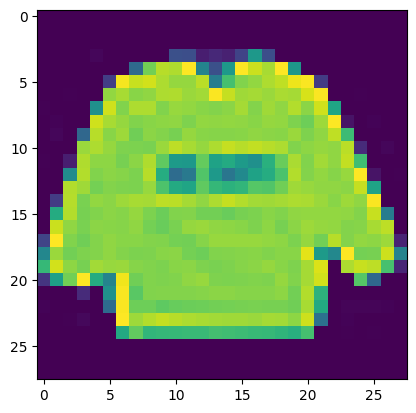

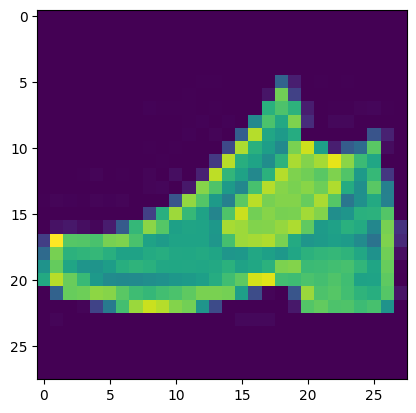

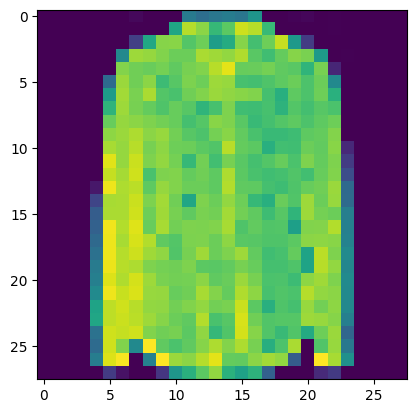

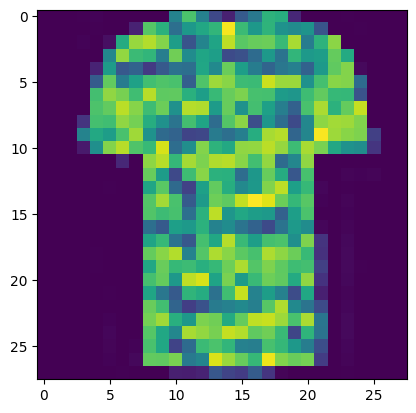

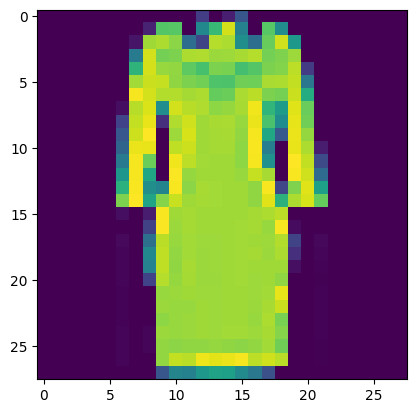

In [5]:
for i in range(5):
    data = train_data[i].reshape(28, 28, 1)
    plt.imshow(data)
    plt.show()

In [ ]:
import matplotlib.pyplot as plt
from collections import defaultdict
BATCH_SIZE = 64
# Tu ma isc R3GAN - i siec z ConvNeXt'a

class Generator(nn.Module):
    def __init__(self, input_size: int = 10, num_classes: int = 10, batch_size: int = 32, lr=1e-3):
        super().__init__()
        self.input_size = input_size
        self.batch_size = batch_size
        self.criterion = nn.MSELoss()
        self.embedding = nn.Embedding(num_embeddings=num_classes, embedding_dim=input_size**2)
        self.network = nn.Sequential(
            # (batch, 1, 10, 10) noise input
            nn.Conv2d(1, 128, kernel_size=5, padding=2),   nn.Dropout(0.25), nn.BatchNorm2d(128), nn.LeakyReLU(0.1), # (batch, 128, 10, 10)
            nn.Conv2d(128, 128, kernel_size=5, padding=2), nn.Dropout(0.25), nn.BatchNorm2d(128), nn.LeakyReLU(0.1), # (batch, 128, 10, 10)
            nn.Upsample(scale_factor=2, mode='nearest'),                                   # (batch, 128, 14, 14)
            nn.Conv2d(128, 64, kernel_size=5, padding=1),  nn.Dropout(0.1), nn.BatchNorm2d(64),  nn.LeakyReLU(0.1), # (batch, 64, 18, 18)
            nn.Conv2d(64, 64, kernel_size=5, padding=1),  nn.Dropout(0.1), nn.BatchNorm2d(64),  nn.LeakyReLU(0.1), # (batch, 64, 16, 16)
            nn.Conv2d(64, 64, kernel_size=5, padding=1),  nn.Dropout(0.1), nn.BatchNorm2d(64),  nn.LeakyReLU(0.1), # (batch, 64, 14, 14)
            nn.Upsample(scale_factor=2, mode='nearest'),                                   # (batch, 64, 28, 28)
            nn.Conv2d(64, 1, kernel_size=5, padding=2),    nn.LeakyReLU(),                   # (batch, 1, 28, 28)
        )
        self.optim = optim.Adam(self.parameters(), lr=lr)
        self.losses = defaultdict(list)
        self.gradients = defaultdict(list)

    def forward(self, class_num: torch.Tensor):
        embedding = torch.tanh( self.embedding(class_num) ).unflatten(-1, (self.input_size, self.input_size)).unsqueeze(1)
        noise = torch.randn(self.batch_size, 1, self.input_size, self.input_size) + embedding
        return self.network(noise) # (batch, 28, 28)

    def set_learning(self, yes_or_no: bool):
        for param in self.parameters():
            param.requires_grad = yes_or_no

    def _log_gradients(self):
        for name, param in self.named_parameters():
            if param.grad is not None and 'weight' in name:
                self.gradients[f'grad/{name}'].append(param.grad.norm().item())

    def training_step(self, discriminator, target_labels):
        fake_images = self(target_labels)
        targets = torch.ones(self.batch_size).unsqueeze(1)
        
        discriminator.set_learning(False)
        assessments = discriminator(fake_images, target_labels)
        discriminator.set_learning(True)
        
        self.optim.zero_grad()

        mse_loss = self.criterion(assessments, targets)
        regularization = self.batch_size / fake_images.std(dim=0).sum()
        loss = mse_loss #+ regularization
        
        self.losses['whole_loss'].append(loss.item())
        self.losses['regularization'].append(regularization.item())
        self.losses['mse_loss'].append(mse_loss.item())

        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.parameters(), max_norm=1.0)
        self._log_gradients()
        self.optim.step()


class Discriminator(nn.Module):
    def __init__(self, input_size: int = 28, num_classes: int = 10, lr: float = 1e-3, batch_size=64):
        super().__init__()
        self.criterion = nn.BCEWithLogitsLoss()
        self.batch_size = batch_size
        self.half_batch = self.batch_size//2
        self.input_size = input_size
        self.embedding = nn.Embedding(num_embeddings=num_classes, embedding_dim=input_size**2)
        self.network = nn.Sequential(*[
            # batch, 1, input_size, input_size
            nn.Conv2d(2, 8, kernel_size=5, padding=2, stride=2), nn.Dropout(0.125), nn.LeakyReLU(0.1), # batch, 2, input_size/2, input_size/2
            nn.Conv2d(8, 8, kernel_size=5, padding=2, stride=2), nn.Dropout(0.125), nn.LeakyReLU(0.1), # batch, 4, input_size/4, input_size/4
            nn.Conv2d(8, 8, kernel_size=5, padding=2, stride=2), nn.Dropout(0.125), nn.LeakyReLU(0.1), # batch, 4, input_size/8, input_size/8
            nn.Conv2d(8, 8, kernel_size=3, padding=1), nn.LeakyReLU(0.1), # batch, 4, input_size/8, input_size/8
            nn.Conv2d(8, 4, kernel_size=3, padding=1), nn.LeakyReLU(0.1), # batch, 4, input_size/8, input_size/8
            nn.Conv2d(4, 4, kernel_size=3, padding=1), nn.LeakyReLU(0.1), # batch, 4, input_size/8, input_size/8
            nn.Flatten(),
            nn.LazyLinear(1)
        ])
        self.optim = optim.Adam(self.parameters(), lr)
        self.losses = defaultdict(list)
        self.gradients = defaultdict(list)

    def set_learning(self, yes_or_no: bool):
        for param in self.parameters():
            param.requires_grad = yes_or_no

    def _log_gradients(self):
        for name, param in self.named_parameters():
            if param.grad is not None and 'weight' in name:
                self.gradients[f'grad/{name}'].append(param.grad.norm().item())

    def forward(self, x, class_num: torch.Tensor):
        embedding = torch.tanh( self.embedding(class_num) ).unflatten(-1, (self.input_size, self.input_size)).unsqueeze(1)
        input = torch.cat([x, embedding], dim=1)
        return self.network(input)
    
    def training_step(self, generator, images, labels): # assuming num_true == num_false
        generator.set_learning(False)
        fake_images = generator(labels[:self.half_batch])
        generator.set_learning(True)
        
        self.optim.zero_grad()

        fake_loss = self.criterion(self(fake_images, labels), torch.zeros(len(fake_images), 1))
        true_loss = self.criterion(self(images, labels), torch.ones(len(images), 1))
        loss = (fake_loss + true_loss) / 2
        self.losses['whole_loss'].append(loss.item())
        self.losses['fake_loss'].append(fake_loss.item())
        self.losses['true_loss'].append(true_loss.item())

        loss.backward() # assuming generator is frozen here
        torch.nn.utils.clip_grad_norm_(self.parameters(), max_norm=1.0)
        self._log_gradients()
        self.optim.step()
        return loss.item()

In [ ]:
from torch.utils.data import DataLoader, TensorDataset

# Preprocess entire dataset once
proper_dimension = np.sqrt(train_data.shape[-1]).astype(int)
processed_data = (train_data / 255).unflatten(-1, (proper_dimension, proper_dimension))
dataloader = DataLoader(TensorDataset(processed_data, train_labels[:len(processed_data)]), batch_size=BATCH_SIZE//2, shuffle=True, drop_last=True)

EPOCHS = 100

generator = Generator(lr=5e-4)
discriminator = Discriminator(lr=5e-4)

generator.train()
discriminator.train()

for epoch in range(EPOCHS):
    for real_images, labels in dataloader:
        labels = labels.long()
        discriminator.training_step(images=real_images.unsqueeze(1), generator=generator, labels=labels)
        generator.training_step(discriminator=discriminator, target_labels=labels)

    class_num = torch.randint(low=0, high=10, size=(BATCH_SIZE//2,)).long()
    
    generator.eval()
    sample = generator(class_num=class_num).detach().permute(0, 2, 3, 1).cpu().numpy()
    plt.imshow(sample[0], cmap='gray')
    plt.axis('off')
    plt.title(f'Epoch {epoch + 1}')
    plt.show()
    generator.train()


plt.title('Discriminator loss')
for label, loss in discriminator.losses.items():
    plt.plot(loss, label=label)
plt.legend()
plt.show()

plt.title('Generator loss')
for label, loss in generator.losses.items():
    plt.plot(loss, label=label)
plt.legend()
plt.show()

plt.title('Discriminator gradient flow')
for label, loss in discriminator.gradients.items():
    plt.plot(np.log10(loss), label=label)
plt.legend()
plt.show()

plt.title('Generator gradient flow')
for label, loss in generator.gradients.items():
    plt.plot(np.log10(loss), label=label)
plt.legend()
plt.show()

In [185]:
torch.save(discriminator.state_dict(), 'last_discriminator.pth')
torch.save(generator.state_dict(), 'last_generator.pth')


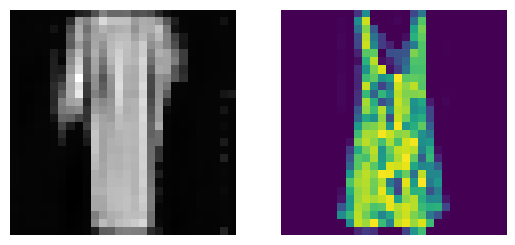

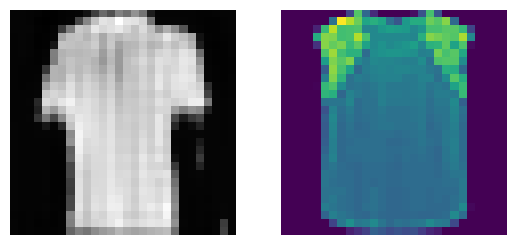

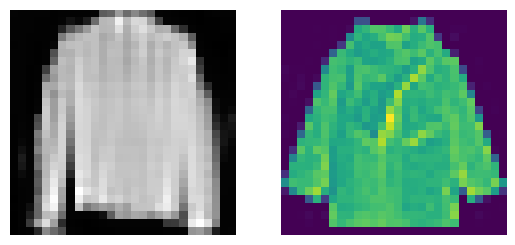

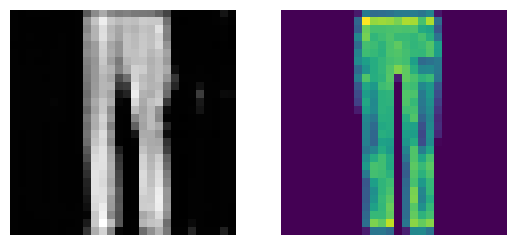

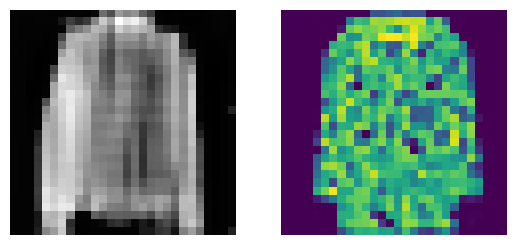

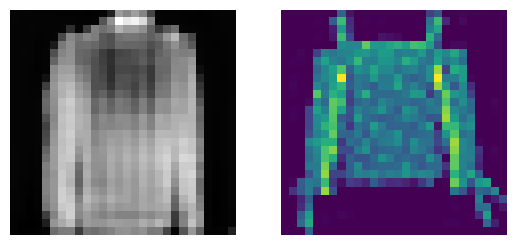

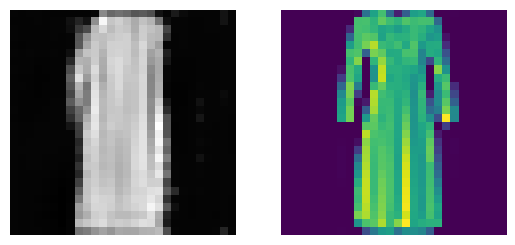

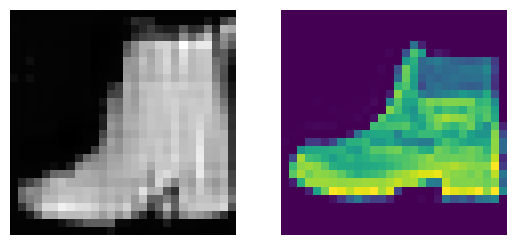

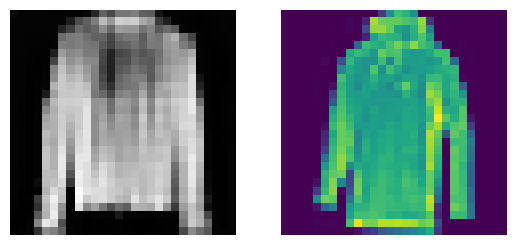

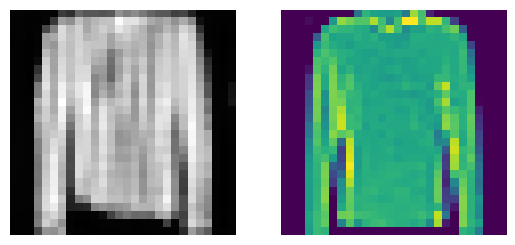

In [ ]:

generator.eval()
real_images, labels = next(iter(dataloader))
labels = labels.long()
fake_images = generator(labels)

for real_image, label, fake_image in zip(real_images[:10], labels[:10], fake_images[:10]):
    fig, ax = plt.subplots(nrows=1, ncols=2)
    ax[0].imshow(fake_image.permute(1, 2, 0).detach().cpu().numpy(), cmap='gray')
    ax[0].axis('off')
    ax[1].imshow(real_image.unsqueeze(0).permute(1, 2, 0).detach().cpu().numpy())
    ax[1].axis('off')
    plt.axis('off')
    plt.show()
    plt.close()